Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: 0
MAT file: /content/drive/MyDrive/LEVIR_Ship_YOLO26/Busan1_S2A_MSIL2A_20210529T020651_N0500_R103_T52SDD_20230227T170302_resampled.mat
Image size: 388 201

Sentinel-2 image size: 388 201
Red shape: (388, 201)
Green shape: (388, 201)
Blue shape: (388, 201)
RGB image shape: (388, 201, 3)


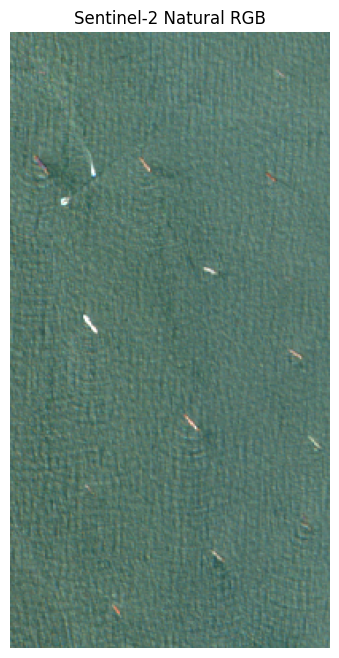


RGB image shape: (388, 201, 3)
RGB dtype: uint8


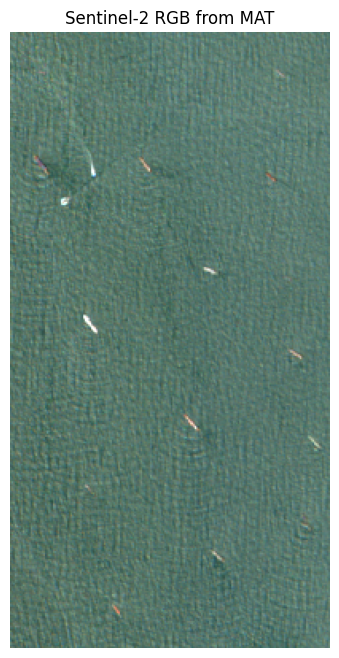


Model loaded:
/content/drive/MyDrive/LEVIR_Ship_YOLO26/Mixed_Finetune/LEVIR_Sentinel2_4to1_30epoch/weights/best.pt

Number of tile positions: 1
1/1 tiles | raw detections = 6

Raw detections: 6
Final detections after NMS: 6

Saved boxes: /content/drive/MyDrive/LEVIR_Ship_YOLO26/Sentinel2_MAT_inference/busan_sentinel2_yolo26_boxes.npy


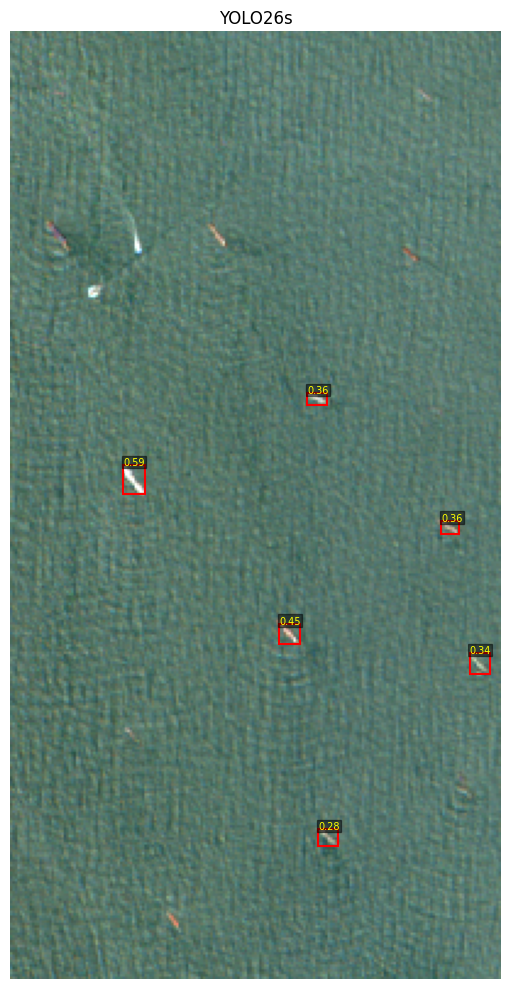


Saved figure: /content/drive/MyDrive/LEVIR_Ship_YOLO26/Sentinel2_MAT_inference/busan1_yolo26_LEVIR_50epoch_LEVIR_S2SD_4to1_30poch_best_detection.png

DETECTION SUMMARY
Total detections: 6
conf >= 0.10: 6
conf >= 0.25: 6
conf >= 0.50: 1

DONE


In [6]:
# ============================================================
# YOLO26s LEVIR-Ship Best Model
# Sliding-window inference on Sentinel-2 .mat RGB
# ============================================================

!pip install -q -U ultralytics torchvision h5py

from ultralytics import YOLO

import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

import torch
from torchvision.ops import nms

from google.colab import drive


# ============================================================
# 1. Mount Google Drive
# ============================================================

drive.mount("/content/drive")


# ============================================================
# 2. Paths
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "LEVIR_Ship_YOLO26/"
#    "YOLO26s_LEVIR_Ship/"
#    "weights/"
#    "best.pt"
# =================================
#    "Sentinel2_Finetune/"
#    "LEVIR_to_Sentinel2/"
#    "weights/"
#    "best.pt"
# =================================
    "Mixed_Finetune/"
    "LEVIR_Sentinel2_4to1_30epoch/"
    "weights/"
    "best.pt"
)


# ------------------------------------------------------------
# Sentinel-2 resampled MAT file
# ------------------------------------------------------------

MAT_PATH = Path(
    "/content/drive/MyDrive/"
    "LEVIR_Ship_YOLO26/"
    #"Busan2_S2A_MSIL2A_20210529T020651_N0500_R103_T52SDD_20230227T170302_resampled.mat"
    #"Busan3_S2A_MSIL2A_20210529T020651_N0500_R103_T52SDD_20230227T170302_resampled.mat"
    "Busan1_S2A_MSIL2A_20210529T020651_N0500_R103_T52SDD_20230227T170302_resampled.mat"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/"
    "LEVIR_Ship_YOLO26/"
    "Sentinel2_MAT_inference"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SAVE_BOX_PATH = (
    OUTPUT_DIR /
    "busan_sentinel2_yolo26_boxes.npy"
)

SAVE_FIG_PATH = (
    OUTPUT_DIR /
    "busan1_yolo26_LEVIR_50epoch_LEVIR_S2SD_4to1_30poch_best_detection.png" #Figure 저장 위치. 수정할 것
#    "busan1_yolo26_LEVIR_50epoch_S2SD_30poch_best_detection.png" #Figure 저장 위치. 수정할 것
#    "busan1_yolo26_LEVIR_50epoch_best_detection.png" #Figure 저장 위치. 수정할 것
)


# ============================================================
# 3. Inference settings
# ============================================================

# LEVIR-Ship crop size
TILE_SIZE = 512

# 20% overlap
OVERLAP = 0.20

STRIDE = int(
    TILE_SIZE * (1 - OVERLAP)
)

# YOLO inference input size
IMGSZ = 640

# 우선 낮게 설정해서 탐지 경향 확인
CONF_THRES = 0.20

# sliding window 중복 box 제거
GLOBAL_NMS_IOU = 0.50

MAX_DET_PER_TILE = 300

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("MAT file:", MAT_PATH)


# ============================================================
# 4. Load Sentinel-2 MAT file
# ============================================================
#
# MATLAB v7.3 MAT 파일은 HDF5 기반이므로 h5py 사용
#
# B4 = Red
# B3 = Green
# B2 = Blue
#
with h5py.File(
    MAT_PATH,
    "r"
) as f:

    red = np.array(
        f["B4"]
    ).astype(np.float32)

    green = np.array(
        f["B3"]
    ).astype(np.float32)

    blue = np.array(
        f["B2"]
    ).astype(np.float32)


H, W = red.shape

print(
    "Image size:",
    H,
    W
)


# ============================================================
# 5. Basic image information
# ============================================================

H, W = red.shape

print()
print(
    "Sentinel-2 image size:",
    H,
    W
)

print(
    "Red shape:",
    red.shape
)

print(
    "Green shape:",
    green.shape
)

print(
    "Blue shape:",
    blue.shape
)


# ============================================================
# 6. Sentinel-2 RGB conversion
# ============================================================
# MAT 내부 값은 이미 reflectance 형태이므로
# 밴드별 percentile stretch 대신 동일 scale 사용
# ============================================================

def reflectance_to_uint8(x, vmin=0.02, vmax=0.25):

    x = x.astype(np.float32)

    x = (x - vmin) / (vmax - vmin)

    x = np.clip(
        x,
        0,
        1
    )

    # 약한 gamma correction
    x = np.power(
        x,
        1 / 1.4
    )

    return (
        x * 255
    ).astype(np.uint8)


# Sentinel-2 true color
# R = B4
# G = B3
# B = B2


# ============================================================
# 7. RGB stack
# ============================================================


rgb = np.stack(
    [
        reflectance_to_uint8(red),
        reflectance_to_uint8(green),
        reflectance_to_uint8(blue)
    ],
    axis=-1
)


print(
    "RGB image shape:",
    rgb.shape
)

plt.figure(
    figsize=(14, 8)
)

plt.imshow(rgb)

plt.title(
    "Sentinel-2 Natural RGB"
)

plt.axis("off")

plt.show()

print()
print(
    "RGB image shape:",
    rgb.shape
)

print(
    "RGB dtype:",
    rgb.dtype
)


# ============================================================
# 8. RGB preview
# ============================================================

plt.figure(
    figsize=(12, 8)
)

plt.imshow(
    rgb
)

plt.title(
    "Sentinel-2 RGB from MAT"
)

plt.axis(
    "off"
)

plt.show()


# ============================================================
# 9. Load trained YOLO26s
# ============================================================

model = YOLO(
    MODEL_PATH
)

print()
print("Model loaded:")
print(MODEL_PATH)


# ============================================================
# 10. Sliding-window inference
# ============================================================

all_boxes = []
all_scores = []


# ------------------------------------------------------------
# 이 MAT 영상은 현재 약 201 x 388 pixel이므로
# TILE_SIZE=512보다 작을 수 있음.
#
# 따라서 작은 영상도 하나의 tile로 처리할 수 있도록
# position 생성
# ------------------------------------------------------------

if W <= TILE_SIZE:

    xs = [0]

else:

    xs = list(
        range(
            0,
            W - TILE_SIZE + 1,
            STRIDE
        )
    )

    last_x = W - TILE_SIZE

    if xs[-1] != last_x:
        xs.append(last_x)


if H <= TILE_SIZE:

    ys = [0]

else:

    ys = list(
        range(
            0,
            H - TILE_SIZE + 1,
            STRIDE
        )
    )

    last_y = H - TILE_SIZE

    if ys[-1] != last_y:
        ys.append(last_y)


print()
print(
    "Number of tile positions:",
    len(xs) * len(ys)
)


tile_count = 0


for y0 in ys:

    for x0 in xs:

        tile_count += 1


        # ------------------------------------------
        # Tile size
        # ------------------------------------------

        tile_w = min(
            TILE_SIZE,
            W - x0
        )

        tile_h = min(
            TILE_SIZE,
            H - y0
        )


        if (
            tile_w < 32 or
            tile_h < 32
        ):

            continue


        # ------------------------------------------
        # Read RGB tile
        # ------------------------------------------

        img_rgb = rgb[
            y0:y0 + tile_h,
            x0:x0 + tile_w
        ]


        # ------------------------------------------
        # Skip nearly empty tiles
        # ------------------------------------------

        if img_rgb.mean() < 2:

            continue


        # ------------------------------------------
        # YOLO prediction
        # ------------------------------------------

        results = model.predict(
            source=img_rgb,
            imgsz=IMGSZ,
            conf=CONF_THRES,
            iou=0.5,
            max_det=MAX_DET_PER_TILE,
            device=DEVICE,
            verbose=False
        )


        boxes = results[0].boxes


        if boxes is None:

            continue


        if len(boxes) == 0:

            continue


        xyxy = (
            boxes.xyxy
            .detach()
            .cpu()
            .numpy()
        )

        scores = (
            boxes.conf
            .detach()
            .cpu()
            .numpy()
        )


        # ------------------------------------------
        # tile coordinate -> full image coordinate
        # ------------------------------------------

        xyxy[:, [0, 2]] += x0
        xyxy[:, [1, 3]] += y0


        all_boxes.append(
            xyxy
        )

        all_scores.append(
            scores
        )


        n_boxes = sum(
            len(b)
            for b in all_boxes
        )

        print(
            f"{tile_count}/"
            f"{len(xs)*len(ys)} tiles | "
            f"raw detections = "
            f"{n_boxes}"
        )


# ============================================================
# 11. Concatenate detections + Global NMS
# ============================================================

if len(all_boxes) == 0:

    print()
    print(
        "No ships detected."
    )

    final_boxes = np.empty(
        (0, 5),
        dtype=np.float32
    )


else:

    all_boxes = np.concatenate(
        all_boxes,
        axis=0
    )

    all_scores = np.concatenate(
        all_scores,
        axis=0
    )


    print()
    print(
        "Raw detections:",
        len(all_boxes)
    )


    boxes_tensor = torch.tensor(
        all_boxes,
        dtype=torch.float32
    )

    scores_tensor = torch.tensor(
        all_scores,
        dtype=torch.float32
    )


    keep = nms(
        boxes_tensor,
        scores_tensor,
        GLOBAL_NMS_IOU
    )


    keep = (
        keep
        .cpu()
        .numpy()
    )


    final_xyxy = all_boxes[
        keep
    ]

    final_scores = all_scores[
        keep
    ]


    final_boxes = np.column_stack(
        [
            final_xyxy,
            final_scores
        ]
    )


    print(
        "Final detections after NMS:",
        len(final_boxes)
    )


# ============================================================
# 12. Save bounding boxes
# ============================================================
#
# columns:
# x1, y1, x2, y2, confidence
# ============================================================

np.save(
    SAVE_BOX_PATH,
    final_boxes
)

print()
print(
    "Saved boxes:",
    SAVE_BOX_PATH
)


# ============================================================
# 13. Plot detections
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 10)
)

ax.imshow(
    rgb
)


for box in final_boxes:

    x1, y1, x2, y2, conf = box


    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=1.5,
        edgecolor="red"
    )

    ax.add_patch(
        rect
    )


    ax.text(
        x1,
        y1,
        f"{conf:.2f}",
        fontsize=7,
        color="yellow",
        bbox=dict(
            facecolor="black",
            alpha=0.5,
            pad=1
        )
    )


ax.set_title(
    "YOLO26s"
)

ax.axis(
    "off"
)

plt.tight_layout()

plt.savefig(             #figure 저장
    SAVE_FIG_PATH,
    dpi=200,
   bbox_inches="tight"
)

plt.show()


print()
print(
    "Saved figure:",
    SAVE_FIG_PATH
)


# ============================================================
# 14. Confidence summary
# ============================================================

print()
print(
    "=" * 60
)

print(
    "DETECTION SUMMARY"
)

print(
    "=" * 60
)

print(
    "Total detections:",
    len(final_boxes)
)


if len(final_boxes) > 0:

    print(
        "conf >= 0.10:",
        np.sum(
            final_boxes[:, 4] >= 0.10
        )
    )

    print(
        "conf >= 0.25:",
        np.sum(
            final_boxes[:, 4] >= 0.25
        )
    )

    print(
        "conf >= 0.50:",
        np.sum(
            final_boxes[:, 4] >= 0.50
        )
    )


print()
print("DONE")